## Parsing UPENN GBM

## Imports

In [ ]:

import os
import sys
import torch
import torch.nn as nn
import numpy as np
import torchvision.transforms as transforms
import torchvision.datasets as Datasets
import pandas as pd
from pathlib import Path

pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)

from src import *

# Load config file
config = global_config.config


## CSVs

In [2]:

radiology_mapping = pd.read_csv(os.path.join(config.upenn_dir, 'radiology_mapping.csv'))
display(radiology_mapping)


,PatientID,ImageID,RadiologyID,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,C1230738,7316UP-2837,NaN,NaN,NaN,NaN,NaN,NaN
1,C1230738,7316UP-3741,NaN,NaN,NaN,NaN,NaN,NaN
2,C1245129,7316UP-2923,UPENN-GBM-00528,NaN,NaN,NaN,NaN,NaN
3,C1245129,7316UP-3639,UPENN-GBM-00528,NaN,NaN,NaN,NaN,NaN
4,C204057,7316UP-302,UPENN-GBM-00145,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
66,C827913,7316UP-2058,UPENN-GBM-00459,NaN,NaN,NaN,NaN,NaN
67,C827913,7316UP-2333,UPENN-GBM-00459,NaN,NaN,NaN,NaN,NaN
68,C827913,7316UP-2527,UPENN-GBM-00459,NaN,NaN,NaN,NaN,NaN
69,C846363,7316UP-2100,UPENN-GBM-00460,NaN,NaN,NaN,NaN,NaN


In [3]:

acquisition = pd.read_csv(os.path.join(config.upenn_dir, 'UPENN-GBM_acquisition.csv'))
display(acquisition)


,ID,Manufacturer,Model,Magnetic Field Strength,T1 Imaging Frequency,T1 Repetition Time,T1 Echo Time,T1 Inversion Time,T1 Flip Angle,T1 Pixel Spacing,...,DTI Echo Time,DTI Flip Angle,DTI Pixel Spacing,DTI Slice Thickness,DSC Imaging Frequency,DSC Repetition Time,DSC Echo Time,DSC Flip Angle,DSC Pixel Spacing,DSC Slice Thickness
0,UPENN-GBM-00001_11,SIEMENS,TrioTim,3.0,123.256776,1760.0,3.10,950.0,15,0.9765625\0.9765625,...,83.0,90.0,2.34375\2.34375,3.0,123.256697,2000.0,45.0,90.0,1.71875\1.71875,3.0
1,UPENN-GBM-00002_11,SIEMENS,TrioTim,3.0,123.256765,1760.0,3.87,950.0,15,0.9765625\0.9765625,...,83.0,90.0,1.71875\1.71875,3.0,123.256628,2000.0,45.0,90.0,1.6875\1.6875,3.0
2,UPENN-GBM-00003_11,SIEMENS,TrioTim,3.0,123.256642,1760.0,3.10,950.0,15,0.9765625\0.9765625,...,91.0,90.0,1.71875\1.71875,3.0,123.256655,2000.0,45.0,90.0,1.71875\1.71875,3.0
3,UPENN-GBM-00004_11,SIEMENS,TrioTim,3.0,123.256789,1760.0,3.10,950.0,15,0.9765625\0.9765625,...,83.0,90.0,1.71875\1.71875,3.0,123.256744,2000.0,45.0,90.0,1.71875\1.71875,3.0
4,UPENN-GBM-00005_11,SIEMENS,TrioTim,3.0,123.256727,1760.0,3.10,950.0,15,0.9765625\0.9765625,...,83.0,90.0,1.71875\1.71875,3.0,123.256677,2000.0,45.0,90.0,1.71875\1.71875,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,UPENN-GBM-00626_21,SIEMENS,TrioTim,3.0,123.256467,1760.0,3.11,950.0,15,0.9765625\0.9765625,...,86.0,90.0,1.71875\1.71875,3.0,123.256457,2000.0,45.0,90.0,1.71875\1.71875,3.0
667,UPENN-GBM-00627_21,SIEMENS,TrioTim,3.0,123.257151,1760.0,3.11,950.0,15,0.9765625\0.9765625,...,86.0,90.0,1.71875\1.71875,3.0,123.257125,2000.0,45.0,90.0,1.71875\1.71875,3.0
668,UPENN-GBM-00628_21,SIEMENS,Verio,3.0,123.261026,1760.0,3.15,950.0,15,0.48828125\0.48828125,...,100.0,90.0,1.71875\1.71875,3.0,123.261118,2000.0,45.0,90.0,1.71875\1.71875,4.0
669,UPENN-GBM-00629_21,SIEMENS,TrioTim,3.0,123.257137,1760.0,3.11,950.0,15,0.9765625\0.9765625,...,86.0,90.0,1.71875\1.71875,3.0,123.257048,2000.0,45.0,90.0,1.71875\1.71875,4.0


In [4]:

params = pd.read_csv(os.path.join(config.upenn_dir, 'UPENN-GBM_CaPTk_fe_params.csv'))
display(params)


,FeatureName,ParamName,Type,Range,Default,Comments
0,Generic,Quantization_Extent,String,Image:ROI,ROI,Whether the quantization of Intensities is sup...
1,Generic,Quantization_Type,String,FixedBinNumber:FixedBinSize:Equal,FixedBinNumber,FixedBinNumber (FBN): the bins are uniformly d...
2,Generic,Resampling,mm,0:10,1.0,Resamples all images and masks to this value o...
3,Generic,ResamplingInterpolator_Image,mm,Nearest:Linear:BSpline,Linear,Type of interpolator to use if resampling is h...
4,Generic,ResamplingInterpolator_Mask,mm,Nearest:NearestLabel:Linear:BSpline,Nearest,Type of interpolator to use if resampling is h...
5,Generic,SliceComputation,Int,(0:1),0,Controls whether non-Intensity features are ca...
6,Generic,NaN-Handling,String,Keep:Remove,Keep,Specify how to handle features with NaN values...
7,Intensity,NaN,NaN,NaN,NaN,NaN
8,Morphologic,Range,Int,(0:25),0,0:largest connected component in ROI; N: all c...
9,Morphologic,Feret,Int,(0:1),0,Whether or not to calculate the Feret Diameter...


In [4]:

radiomic_features = pd.read_csv(os.path.join(config.upenn_dir, 'UPENN-GBM_CaPTk_radiomic_features_list.csv'))
display(radiomic_features)


,FeatureName
0,Intensity_CoefficientOfVariation
1,Intensity_Energy
2,Intensity_InterQuartileRange
3,Intensity_Kurtosis
4,Intensity_Maximum
...,...
139,NGTDM_Coarsness
140,NGTDM_Complexity
141,NGTDM_Contrast
142,NGTDM_Strength


In [5]:

clinical_info = pd.read_csv(os.path.join(config.upenn_dir, 'UPENN-GBM_clinical_info_v2.1.csv'))
#display(clinical_info)
print(clinical_info.columns)
print(list(clinical_info.dtypes))

pd.set_option("display.max_rows", 40)

survival_days = clinical_info['Survival_from_surgery_days_UPDATED']
survival_days = survival_days.drop(survival_days[survival_days == 'Not Available'].index)

print("statistics:")
display(survival_days.describe())

idx_max = survival_days.idxmax()
days_max = survival_days.loc[idx_max]
print(f"Max survival index ({idx_max}), days:")
display(days_max)


Index(['ID', 'Gender', 'Age_at_scan_years',
       'Survival_from_surgery_days_UPDATED', 'Survival_Status',
       'Survival_Censor', 'IDH1', 'MGMT', 'KPS', 'GTR_over90percent',
       'Time_since_baseline_preop', 'PsP_TP_score'],
      dtype='object')
[dtype('O'), dtype('O'), dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('float64')]
statistics:


count     644
unique    471
top        80
freq        5
Name: Survival_from_surgery_days_UPDATED, dtype: object

Max survival index (396), days:


'996'

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def plot_regression(ax, data, gender, age_cutoff, less_than, color):
    # Filter data for gender and age cutoff
    if less_than:
        data_filtered =data[(data['Age_at_scan_years'] >= age_cutoff)]
    else:
        data_filtered =data[(data['Age_at_scan_years'] < age_cutoff)]
        
    X = data_filtered[['Age_at_scan_years']].values.reshape(-1, 1)  
    y = data_filtered['Survival_from_surgery_days_UPDATED'].values  
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Plot data 
    ax.scatter(data_filtered['Age_at_scan_years'], data_filtered['Survival_from_surgery_days_UPDATED'], color=color, alpha=0.5, label=f'{gender} - Age {"<" if age_cutoff == 50 else ">="} {age_cutoff}')
    ax.plot(data_filtered['Age_at_scan_years'], y_pred, color=color, linewidth=2)
    r_squared = model.score(X, y)
    ax.text(0.05, 0.95, f'R^2 = {r_squared:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', color=color)
    
    ax.set_xlabel('Age at Scan (Years)')
    ax.set_ylabel('Survival Time (Days)')
    ax.set_title(f'{gender} - Age {"<" if less_than == False else ">="} {age_cutoff}')

Gender
M    405
F    266
Name: count, dtype: int64


/tmp/ipykernel_1199327/3601151598.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_data['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(demo_data['Survival_from_surgery_days_UPDATED'], errors='coerce')
/tmp/ipykernel_1199327/3601151598.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_data.dropna(subset=['Survival_from_surgery_days_UPDATED'], inplace=True)


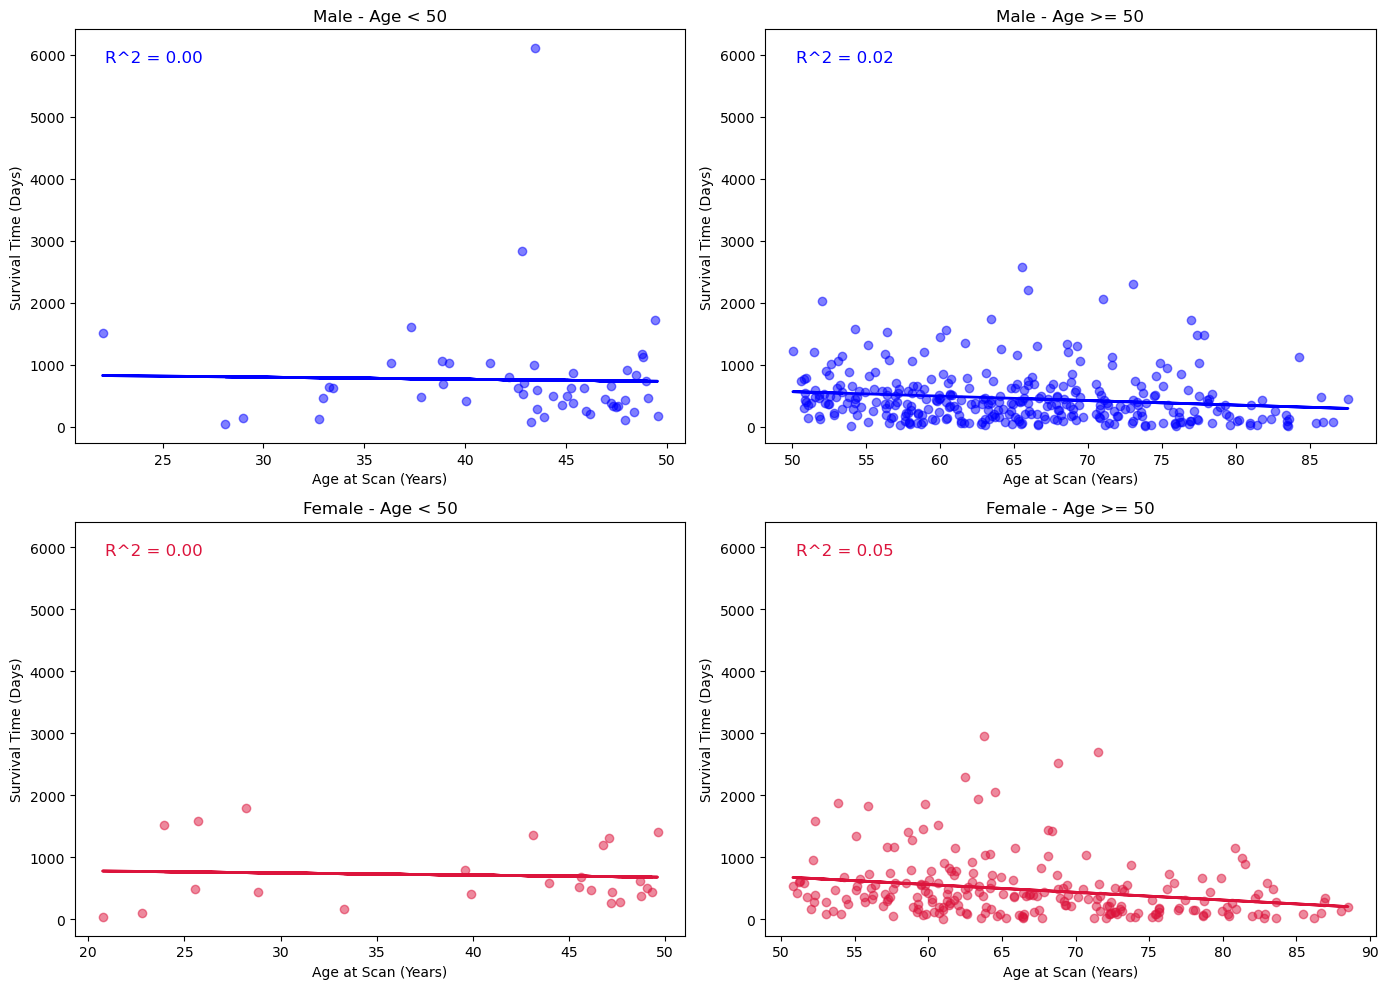

In [ ]:

# Previous glioblastoma models have sugested that age and gender are significant factors in survival time.
print(clinical_info['Gender'].value_counts())
demo_data = clinical_info[['Survival_from_surgery_days_UPDATED', 'Age_at_scan_years', 'Gender']]
demo_data['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(demo_data['Survival_from_surgery_days_UPDATED'], errors='coerce')

demo_data.dropna(subset=['Survival_from_surgery_days_UPDATED'], inplace=True)
age_cutoff = 50
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  
axes = axes.flatten()

males = demo_data[demo_data['Gender'] == 'M']
females = demo_data[demo_data['Gender'] == 'F']

# Male, Age < 
plot_regression(axes[0], males, 'Male', age_cutoff,less_than=False, color='blue')

# Male, Age >= 
plot_regression(axes[1], males, 'Male', age_cutoff,less_than=True, color='blue')

# Female, Age < 
plot_regression(axes[2], females, 'Female', age_cutoff,less_than=False, color='crimson')

# Female, Age >= 
plot_regression(axes[3], females, 'Female', age_cutoff,less_than=True, color='crimson')
y_min = min([ax.get_ylim()[0] for ax in axes])
y_max = max([ax.get_ylim()[1] for ax in axes])

for ax in axes:
    ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [6]:

data_availability = pd.read_csv(os.path.join(config.upenn_dir, 'UPENN-GBM_data_availability.csv'))
display(data_availability)


,ID,Structural imaging,DTI imaging,DSC imaging,Automatic Tumor Segmentation,Corrected Tumor Segmentation,Gender,Age,Overall Survival,IDH1,MGMT,KPS,Extent of Resection,Associated Baseline Scan,Associated Recurrence Scan,PsP_TP score,CaPTk Radiomic Features
0,UPENN-GBM-00001_11,available,available,available,available,available,available,available,not available,available,not available,not available,available,-,not available,not available,available
1,UPENN-GBM-00002_11,available,available,available,available,available,available,available,available,available,not available,not available,available,-,not available,not available,available
2,UPENN-GBM-00003_11,available,available,available,available,available,available,available,not available,available,not available,not available,available,-,not available,not available,available
3,UPENN-GBM-00004_11,available,available,available,available,available,available,available,not available,not available,not available,not available,available,-,not available,not available,available
4,UPENN-GBM-00005_11,available,available,available,available,available,available,available,not available,available,not available,not available,available,-,not available,not available,available
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,UPENN-GBM-00626_21,available,available,available,not available,not available,available,available,not available,available,available,not available,not available,not available,-,available,not available
667,UPENN-GBM-00627_21,available,available,available,not available,not available,available,available,not available,available,not available,not available,not available,not available,-,available,not available
668,UPENN-GBM-00628_21,available,available,available,not available,not available,available,available,not available,available,not available,not available,not available,not available,-,available,not available
669,UPENN-GBM-00629_21,available,available,available,not available,not available,available,available,not available,available,available,not available,not available,not available,-,available,not available


In [7]:

fe_params = pd.read_csv(os.path.join(config.upenn_dir, 'radiomic_features_CaPTk', 'fe_params_UPENN-GBM_CaPTk.csv'))
display(fe_params)


,FeatureName,ParamName,Type,Range,Default,Comments
0,Generic,Quantization_Extent,String,Image:ROI,ROI,Whether the quantization of Intensities is sup...
1,Generic,Quantization_Type,String,FixedBinNumber:FixedBinSize:Equal,FixedBinNumber,FixedBinNumber (FBN): the bins are uniformly d...
2,Generic,Resampling,mm,0:10,1.0,Resamples all images and masks to this value o...
3,Generic,ResamplingInterpolator_Image,mm,Nearest:Linear:BSpline,Linear,Type of interpolator to use if resampling is h...
4,Generic,ResamplingInterpolator_Mask,mm,Nearest:NearestLabel:Linear:BSpline,Nearest,Type of interpolator to use if resampling is h...
5,Generic,SliceComputation,Int,(0:1),0,Controls whether non-Intensity features are ca...
6,Generic,NaN-Handling,String,Keep:Remove,Keep,Specify how to handle features with NaN values...
7,Intensity,NaN,NaN,NaN,NaN,NaN
8,Morphologic,Range,Int,(0:25),0,0:largest connected component in ROI; N: all c...
9,Morphologic,Feret,Int,(0:1),0,Whether or not to calculate the Feret Diameter...


In [8]:

radiomic_features_example = pd.read_csv(os.path.join(config.upenn_dir, 'radiomic_features_CaPTk', 'Radiomic_Features_CaPTk_segm_DTI_TR_NC.csv'))
display(radiomic_features_example)


,SubjectID,DTI_TR_NC_Intensity_CoefficientOfVariation,DTI_TR_NC_Intensity_Energy,DTI_TR_NC_Intensity_InterQuartileRange,DTI_TR_NC_Intensity_Kurtosis,DTI_TR_NC_Intensity_Maximum,DTI_TR_NC_Intensity_Mean,DTI_TR_NC_Intensity_MeanAbsoluteDeviation,DTI_TR_NC_Intensity_Median,DTI_TR_NC_Intensity_MedianAbsoluteDeviation,...,DTI_TR_NC_GLSZM_Bins-16_Radius-1_ZoneSizeMean,DTI_TR_NC_GLSZM_Bins-16_Radius-1_ZoneSizeNonUniformity,DTI_TR_NC_GLSZM_Bins-16_Radius-1_ZoneSizeNoneUniformityNormalized,DTI_TR_NC_GLSZM_Bins-16_Radius-1_ZoneSizeVariance,DTI_TR_NC_NGTDM_Busyness,DTI_TR_NC_NGTDM_Coarsness,DTI_TR_NC_NGTDM_Complexity,DTI_TR_NC_NGTDM_Contrast,DTI_TR_NC_NGTDM_Strength,DTI_TR_NC_LBP_Radius-1_Bins-16_LBP
0,UPENN-GBM-00002_11,0.279086,349440992,77,1.576605,225,145.251464,-3.072193e-12,137.0,8.251464,...,45.732143,63.184524,0.188049,38849.571110,96.005993,0.000090,872.455321,1.180889,0.009174,131138.540700
1,UPENN-GBM-00003_11,0.179628,405076154,36,4.818454,212,170.467565,1.238819e-13,185.0,-14.532435,...,25.241121,102.383178,0.191370,60777.999800,125.814521,0.000028,2032.548289,0.823439,0.008685,104112.458100
2,UPENN-GBM-00005_11,0.155807,26425074,15,3.762921,119,71.390360,-5.898824e-14,70.0,1.390360,...,27.661202,25.644809,0.140136,10446.999970,35.684490,0.000292,656.036971,0.307946,0.035726,45339.020620
3,UPENN-GBM-00006_11,0.137042,248470500,32,2.523066,211,163.809660,7.784840e-13,164.0,-0.190340,...,48.345745,35.393617,0.188264,36100.683650,60.654442,0.000103,1279.093436,0.709612,0.011198,79709.991680
4,UPENN-GBM-00007_11,0.219803,195715356,28,3.805651,174,89.326011,7.875819e-13,88.0,1.326011,...,51.880266,85.926829,0.190525,105310.500100,168.515345,0.000050,777.896073,0.289564,0.005810,223239.448800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,UPENN-GBM-00437_11,0.242488,424988346,45,2.963672,251,136.695685,-2.645335e-12,137.0,-0.304315,...,30.819225,161.154950,0.231212,55855.000320,145.425916,0.000051,838.533895,0.411469,0.005160,237629.892500
219,UPENN-GBM-00438_11,0.229979,480101,24,1.916967,86,62.982609,-9.885812e-16,67.0,-4.017391,...,2.738095,10.761905,0.256236,5.764739,0.650300,0.012351,880.000407,1.589136,1.300810,1427.876130
220,UPENN-GBM-00439_11,0.125926,4157943,11,2.335564,84,63.786282,1.491716e-14,64.0,-0.213718,...,10.702128,12.765957,0.135808,243.741059,6.678038,0.001332,821.446441,0.737733,0.117916,9432.826483
221,UPENN-GBM-00440_11,0.206219,6262416,18,3.566674,118,70.989933,5.484055e-15,69.0,1.989933,...,10.642857,14.178571,0.126594,236.676020,8.731826,0.001066,751.956769,0.493830,0.109086,12214.318740


## MR Images

In [10]:
pd.set_option('display.max_rows', 2)
metadata = pd.read_csv(os.path.join(config.upenn_dir, 'MR_Images', 'UPENN-GBM_DownloadManifest20221129', 'metadata.csv'))
display(metadata)


,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,File Size,File Location,Download Timestamp
0,1.3.6.1.4.1.14519.5.2.1.7211183242553540454075...,UPENN-GBM,NO,https://doi.org/10.7937/TCIA.709X-DN49,UPENN-GBM-00001,1.3.6.1.4.1.14519.5.2.1.3257229810771891571048...,BRAINROUTINE,02-06-2002,t2Flairaxial ProcessedCaPTk,SIEMENS,MR,MR Image Storage,1.2.840.10008.5.1.4.1.1.4,60,6.08 MB,./UPENN-GBM/UPENN-GBM-00001/02-06-2002-BRAINRO...,2025-02-11T09:26:42.180303287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,1.3.6.1.4.1.14519.5.2.1.1111858064280179117867...,UPENN-GBM,NO,https://doi.org/10.7937/TCIA.709X-DN49,UPENN-GBM-00469,1.3.6.1.4.1.14519.5.2.1.5784145606454665884673...,BrainTumor,02-16-2012,t1 axial 3DTERA ProcessedCaPTk,SIEMENS,MR,MR Image Storage,1.2.840.10008.5.1.4.1.1.4,192,19.46 MB,./UPENN-GBM/UPENN-GBM-00469/02-16-2012-BrainTu...,2025-02-13T22:46:56.452022011
